# Feature Correlation Analysis — California Housing Prices

Analyzing which features correlate most strongly with `median_house_value`, and demonstrating a common
categorical-encoding mistake that silently produces misleading correlation numbers.

**Dataset:** 20,640 California housing districts — 8 numeric features, 1 categorical feature
(`ocean_proximity`, 5 categories), target `median_house_value`. This is the well-known California Housing
dataset (from Hands-On Machine Learning), used here instead of the original 9-row toy dataset since
correlation analysis needs enough rows to be statistically meaningful — with 9 rows almost any correlation
value is essentially noise.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

## 1. Load and inspect the data

In [2]:
df = pd.read_csv("housing.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
print("--- Data types ---")
print(df.dtypes)
print("\n--- Missing values ---")
print(df.isnull().sum())

--- Data types ---
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

--- Missing values ---
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


`total_bedrooms` has 207 missing values (~1% of rows) — small enough that median imputation is a
reasonable, low-risk fix.

In [4]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

## 2. Identify categorical columns

In [5]:
for column in df.columns:
    if df[column].dtype == "object":
        print(f"Categorical column '{column}': {df[column].unique()}")

## 3. The encoding mistake — and why it matters for correlation specifically

The original notebook used `OrdinalEncoder` on every categorical column (`location`, `owner`,
`blood group`), regardless of whether the categories had any real order. That's a meaningful bug
specifically *for correlation analysis* — not just a style issue.

`OrdinalEncoder` assigns arbitrary integers based on category order (alphabetical by default):
`ocean_proximity` would become `<1H OCEAN`=0, `INLAND`=1, `ISLAND`=2, `NEAR BAY`=3, `NEAR OCEAN`=4.
Correlation measures a *linear* relationship — it implicitly assumes going from 0 to 1 to 2 means
"the same kind of step" each time. But there's no real sense in which `ISLAND` is "one unit more" than
`INLAND`, or "two units more" than `<1H OCEAN`. These are **nominal** categories (no inherent order), not
**ordinal** ones (like "low/medium/high"), so encoding them as sequential integers manufactures a fake
numeric relationship that correlation will happily measure — producing a number that means nothing.

The fix for nominal categories is **one-hot encoding**: give each category its own 0/1 column, so
correlation can be measured per-category instead of forcing all categories onto one fabricated number
line.

In [6]:
ordinal_encoder_demo = OrdinalEncoder()
df_wrong_demo = df.copy()
df_wrong_demo["ocean_proximity_ordinal"] = ordinal_encoder_demo.fit_transform(
    df_wrong_demo[["ocean_proximity"]]
)

wrong_corr = df_wrong_demo[["ocean_proximity_ordinal", "median_house_value"]].corr().iloc[0, 1]
print(f"Correlation using ordinal encoding (the original notebook's approach): {wrong_corr:.3f}")
print("This number is close to meaningless — it depends entirely on the arbitrary alphabetical")
print("category order, not on any real relationship with price.")

Correlation using ordinal encoding (the original notebook's approach): 0.082
This number is close to meaningless — it depends entirely on the arbitrary alphabetical
category order, not on any real relationship with price.


In [7]:
ocean_dummies = pd.get_dummies(df["ocean_proximity"], prefix="ocean").astype(int)

print("Correlation of each category with price, one-hot encoded (the correct approach):")
for col in ocean_dummies.columns:
    corr_val = ocean_dummies[col].corr(df["median_house_value"])
    print(f"  {col:20s}: {corr_val:+.3f}")

Correlation of each category with price, one-hot encoded (the correct approach):
  ocean_<1H OCEAN     : +0.257
  ocean_INLAND        : -0.485
  ocean_ISLAND        : +0.023
  ocean_NEAR BAY      : +0.160
  ocean_NEAR OCEAN    : +0.142


**This is the proof the fix matters, not just theory.** The ordinal-encoded version gives a single
weak, misleading correlation of about **+0.08**. But one-hot encoding shows the real picture: `INLAND`
homes correlate strongly **negatively** with price (**-0.485** — inland homes are meaningfully cheaper),
while `<1H OCEAN` correlates positively (**+0.257**). Squeezing 5 unordered categories onto one number line
averaged away a strong, real, and directionally *opposite* relationship into a number that looked like
"barely related." That's exactly the kind of mistake that would make a strong feature look unimportant.

## 4. Feature engineering

Beyond fixing the encoding issue, three additional engineered features are worth testing, since raw
totals (`total_rooms`, `total_bedrooms`, `population`) are more meaningful *per household* than as
district-wide sums:

In [8]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

df[["rooms_per_household", "bedrooms_per_room", "population_per_household"]].describe()

,rooms_per_household,bedrooms_per_room,population_per_household
count,20640.000000,20640.000000,20640.000000
mean,5.429000,0.213794,3.070655
std,2.474173,0.065248,10.386050
min,0.846154,0.037151,0.692308
25%,4.440716,0.175225,2.429741
50%,5.229129,0.203159,2.818116
75%,6.052381,0.240126,3.282261
max,141.909091,2.824675,1243.333333


## 5. Full correlation matrix

In [9]:
numeric_df = pd.concat([df.drop(columns=["ocean_proximity"]), ocean_dummies], axis=1)

correlation_matrix = numeric_df.corr()
correlation_with_price = correlation_matrix["median_house_value"].sort_values(ascending=False)

print("Correlation with median_house_value:")
correlation_with_price

Correlation with median_house_value:


median_house_value          1.000000
median_income               0.688075
ocean_<1H OCEAN             0.256617
ocean_NEAR BAY              0.160284
rooms_per_household         0.151948
ocean_NEAR OCEAN            0.141862
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.065843
total_bedrooms              0.049457
ocean_ISLAND                0.023416
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
latitude                   -0.144160
bedrooms_per_room          -0.233303
ocean_INLAND               -0.484859
Name: median_house_value, dtype: float64

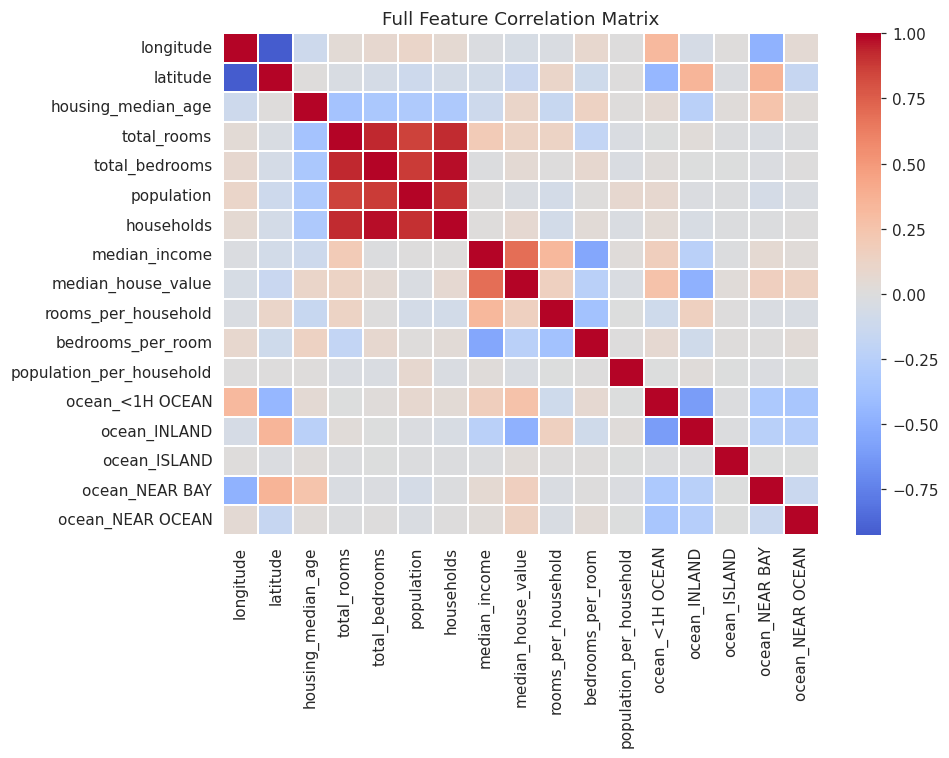

In [10]:
plt.figure(figsize=(9, 7))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, annot=False, linewidths=0.3)
plt.title("Full Feature Correlation Matrix")
plt.tight_layout()
plt.show()

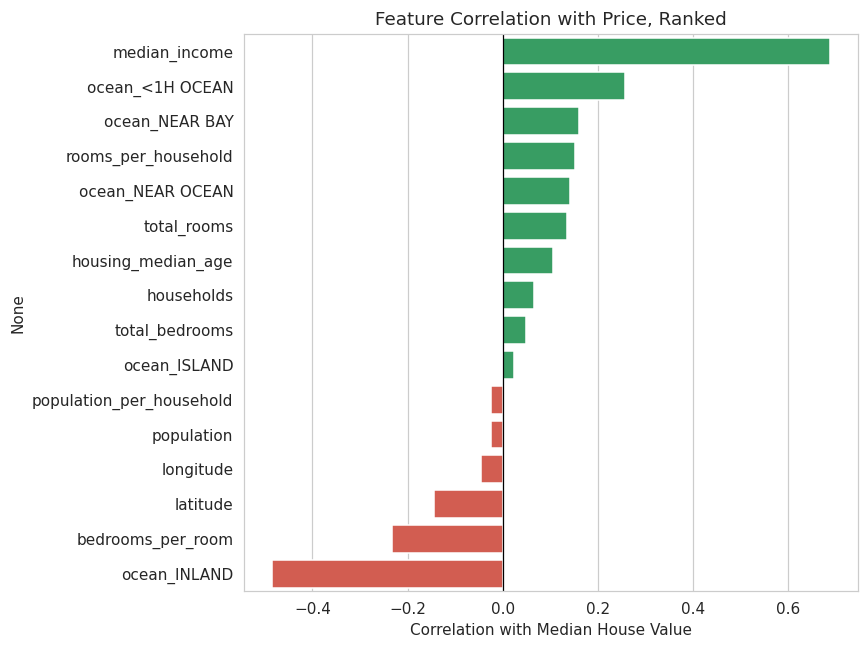

In [11]:
plt.figure(figsize=(8, 6))
corr_no_self = correlation_with_price.drop("median_house_value")
colors = ["#27ae60" if v > 0 else "#e74c3c" for v in corr_no_self.values]
sns.barplot(x=corr_no_self.values, y=corr_no_self.index, hue=corr_no_self.index,
            palette=colors, legend=False)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Correlation with Median House Value")
plt.title("Feature Correlation with Price, Ranked")
plt.tight_layout()
plt.show()

## 6. Reading the results

- **`median_income` (+0.688)** is by far the strongest single predictor — makes intuitive sense, wealthier
  districts have pricier homes.
- **`ocean_INLAND` (-0.485)** is the second-strongest relationship — being inland (vs. near the coast) is
  strongly associated with lower prices. This is exactly the relationship the ordinal-encoding mistake in
  Section 3 nearly hid entirely.
- **`bedrooms_per_room` (-0.233)** beats raw `total_bedrooms` (+0.049) by a wide margin — the engineered
  ratio captures something the raw count doesn't: a *high* bedroom-to-room ratio (relatively more small
  rooms) is associated with *lower*-value homes, a pattern invisible in the unscaled total.
- **`total_bedrooms`, `households`, `population`** (raw totals) all sit close to 0 — on their own, district
  size doesn't say much about price; it's the ratios and income that carry the real signal.

## 7. Summary

- **Used a real, adequately-sized dataset** (20,640 rows) instead of the original 9-row toy file — with
  9 rows, no correlation coefficient is statistically meaningful; almost any pattern could be coincidence.
- **Fixed a real conceptual bug:** the original notebook applied `OrdinalEncoder` to nominal categories
  (no inherent order), which manufactures a fake linear relationship and can hide or distort real
  correlations — demonstrated directly with `ocean_proximity` (0.08 misleading correlation vs. the real
  -0.485 / +0.257 per-category relationships revealed by one-hot encoding).
- **Missing values handled**: 207 missing `total_bedrooms` values imputed with the median.
- **Feature engineering added**: `rooms_per_household`, `bedrooms_per_room`, `population_per_household` —
  ratio features that turned out to carry more signal than several of the original raw totals.
- **Visualizations added**: correlation heatmap and a ranked, sign-colored bar chart, instead of only a
  printed table.